### Linear Regression Using the Model Class
This notebook is based on the Coursera Course: Foundations and Core Concepts of PyTorch.

In [1]:
import graphlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader 
import seaborn as sns

          Unnamed: 0   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
0          Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
1      Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
2         Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
3     Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
4  Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

   carb  
0     4  
1     4  
2     1  
3     1  
4     2  


<Axes: xlabel='wt', ylabel='mpg'>

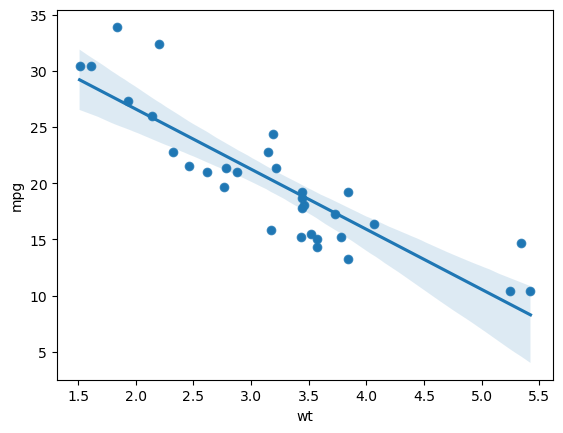

In [25]:
# Data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
print(cars.head())

# Visualize the model
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

In [26]:
# Convert the data to tensor formats
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
print(X_np[:4])  # Peak at the first four values to see the shape

y_list = cars.mpg.values.tolist()
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)

# Create tensors out of the data (two ways)
X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

print("X.shape: {}".format(X.shape))
print("y.shape: {}".format(y_true.shape))

[[2.62 ]
 [2.875]
 [2.32 ]
 [3.215]]
X.shape: torch.Size([32, 1])
y.shape: torch.Size([32, 1])


In [27]:
# Define the Model Class and the Dataloader

class LinearRegressionTorch(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        out = self.linear(x)
        return out

class LinearRegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (torch.as_tensor(self.X[idx], dtype=torch.float32),
                torch.as_tensor(self.y[idx], dtype=torch.float32))

train_loader = DataLoader(dataset = LinearRegressionDataset(X_np, y_np), batch_size=2, shuffle=True)


In [32]:
INPUT_DIM = 1
OUTPUT_DIM = 1

model = LinearRegressionTorch(INPUT_DIM, OUTPUT_DIM)
model.train()

# Linear regression makes MSE appropriate
LOSS_FUNC = nn.MSELoss()
LR = 0.02
OPTIMIZER = torch.optim.SGD(model.parameters(), lr=LR)

NUM_EPOCHS = 1000


In [33]:
losses, slopes, biases = [], [], []

for epoch in range(NUM_EPOCHS):
    epoch_loss_sum = 0.0
    n_seen = 0

    for j, (X, y) in enumerate(train_loader):
        OPTIMIZER.zero_grad()

        # forward pass
        y_pred = model(X)

        # compute loss
        loss = LOSS_FUNC(y_pred, y)
        losses.append(loss.item())

        # Backprop
        loss.backward()

        # Update the weights
        OPTIMIZER.step()

        # Accumulate the epoch aervage
        batch_size = X.size(0)
        epoch_loss_sum += loss.item() * batch_size
        n_seen += batch_size

    avg_loss = epoch_loss_sum / n_seen
    losses.append(avg_loss)

    slope = model.linear.weight[0, 0].item()
    bias  = model.linear.bias[0].item()

    slopes.append(slope)
    biases.append(bias)

    print_every = 100

    if epoch % print_every == 0:
        print(f"Epoch {epoch:5d} | Loss: {avg_loss:.6f}")

# We can compare these to the statistical regression model to see how close we are
print(f"Bias at end: {biases[-1]}")
print(f"Slope at the end: {slopes[-1]}")

Epoch     0 | Loss: 135.810125
Epoch   100 | Loss: 10.840020
Epoch   200 | Loss: 9.809095
Epoch   300 | Loss: 10.716803
Epoch   400 | Loss: 10.733278
Epoch   500 | Loss: 9.827053
Epoch   600 | Loss: 9.292495
Epoch   700 | Loss: 10.492222
Epoch   800 | Loss: 11.191157
Epoch   900 | Loss: 9.189572
Bias at end: 37.19013214111328
Slope at the end: -5.409586429595947


<Axes: >

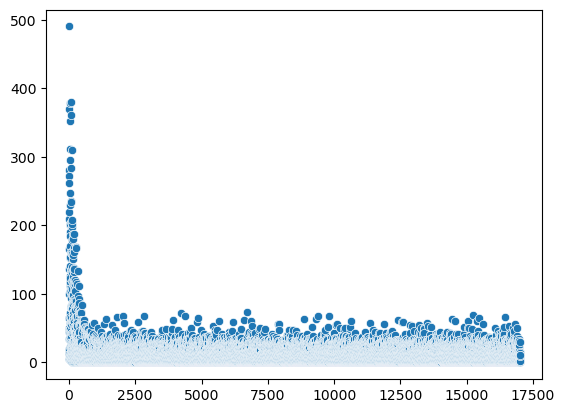

In [35]:
# Visualize the model training
sns.scatterplot(x=range(len(losses)), y=losses)

<Axes: >

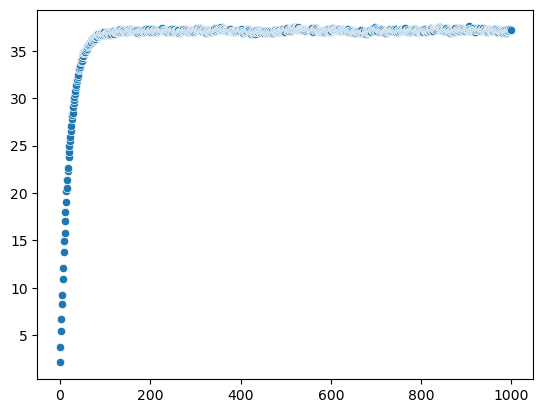

In [36]:
# Visualize the bias develpment
sns.scatterplot(x=range(len(biases)), y=biases)

<Axes: >

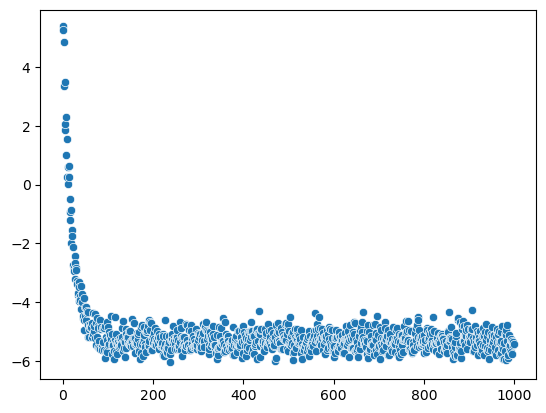

In [37]:
# Visualize the slopes
sns.scatterplot(x=range(len(slopes)), y=slopes)

<Axes: >

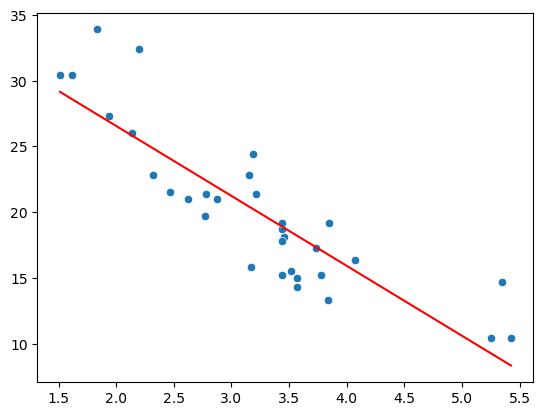

In [45]:
y_pred = model(X).data.numpy().reshape(-1)
sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred, color='red')